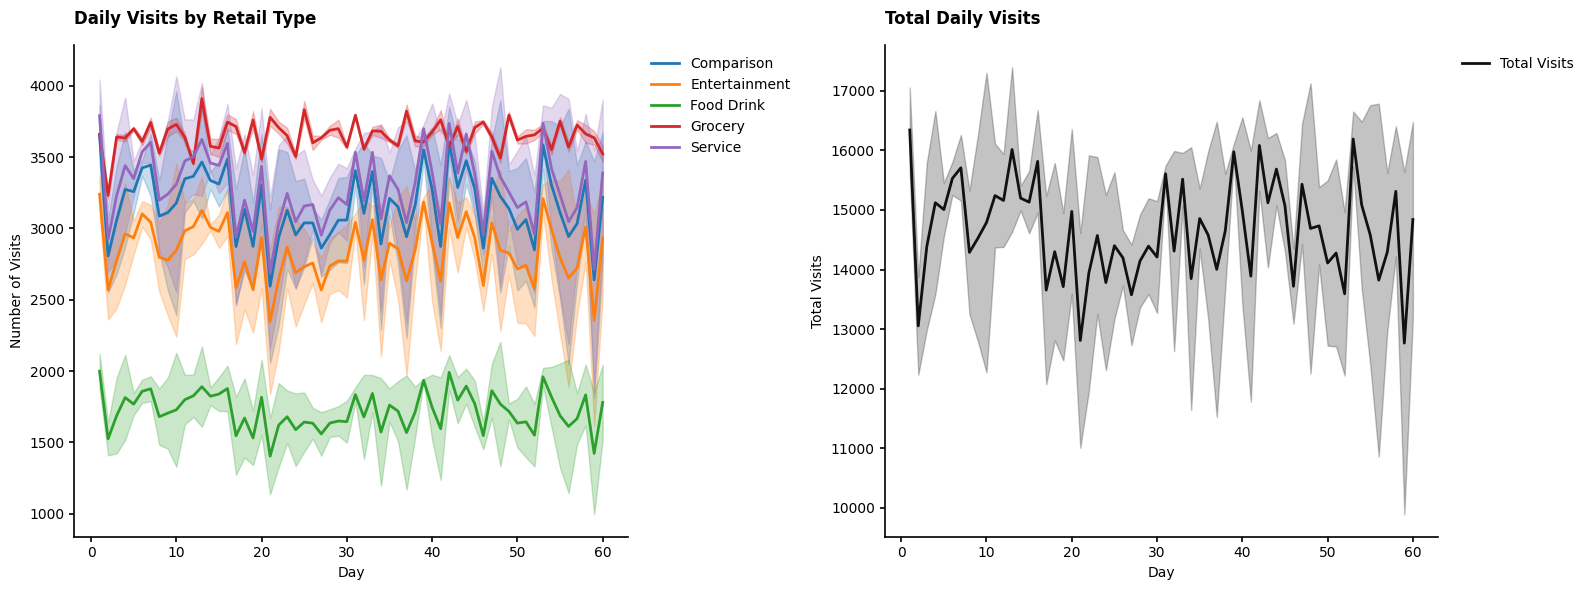

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

folder = Path(r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\for avg')
files = sorted(folder.glob('*.csv'))

retail_types = ['comparison', 'entertainment', 'food_drink', 'grocery', 'service']
use_rows = 60

dfs = []
for path in files:
    tmp = pd.read_csv(path)
    if 'Day' not in tmp.columns:
        raise ValueError(f'Missing Day column in {path.name}')
    cols = ['Day'] + [c for c in retail_types + ['Total_Visits'] if c in tmp.columns]
    tmp = tmp.loc[:, cols].head(use_rows).copy()
    dfs.append(tmp)

df_all = pd.concat(dfs, keys=[p.stem for p in files], names=['source']).reset_index(level='source')
agg = df_all.groupby('Day').agg({c: ['mean', 'std'] for c in retail_types + ['Total_Visits']})
agg.columns = [f'{col}_{stat}' for col, stat in agg.columns]
df = agg.reset_index()

for col in retail_types + ['Total_Visits']:
    if f'{col}_std' not in df.columns:
        df[f'{col}_std'] = 0.0
    df[f'{col}_std'] = df[f'{col}_std'].fillna(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for col in retail_types:
    legend_name = col.replace('_', ' ').title()
    line, = ax1.plot(df['Day'], df[f'{col}_mean'], linewidth=2, label=legend_name)
    color = line.get_color()
    lower = df[f'{col}_mean'] - df[f'{col}_std']
    upper = df[f'{col}_mean'] + df[f'{col}_std']
    ax1.fill_between(df['Day'], lower, upper, color=color, alpha=0.25)

ax1.set_title('Daily Visits by Retail Type', fontweight='bold', loc='left', pad=15)
ax1.set_xlabel('Day')
ax1.set_ylabel('Number of Visits')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)
ax1.tick_params(width=1.2)
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax1.grid(False)

line, = ax2.plot(df['Day'], df['Total_Visits_mean'], linewidth=2, color='#111111', label='Total Visits')
color = line.get_color()
lower_total = df['Total_Visits_mean'] - df['Total_Visits_std']
upper_total = df['Total_Visits_mean'] + df['Total_Visits_std']
ax2.fill_between(df['Day'], lower_total, upper_total, color=color, alpha=0.25)

ax2.set_title('Total Daily Visits', fontweight='bold', loc='left', pad=15)
ax2.set_xlabel('Day')
ax2.set_ylabel('Total Visits')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)
ax2.tick_params(width=1.2)
ax2.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax2.grid(False)

plt.tight_layout()
plt.show()

Loading data from: C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\utility_convergence_1779290010.csv
Visualization saved successfully to: C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\stability_metrics_visualization.png


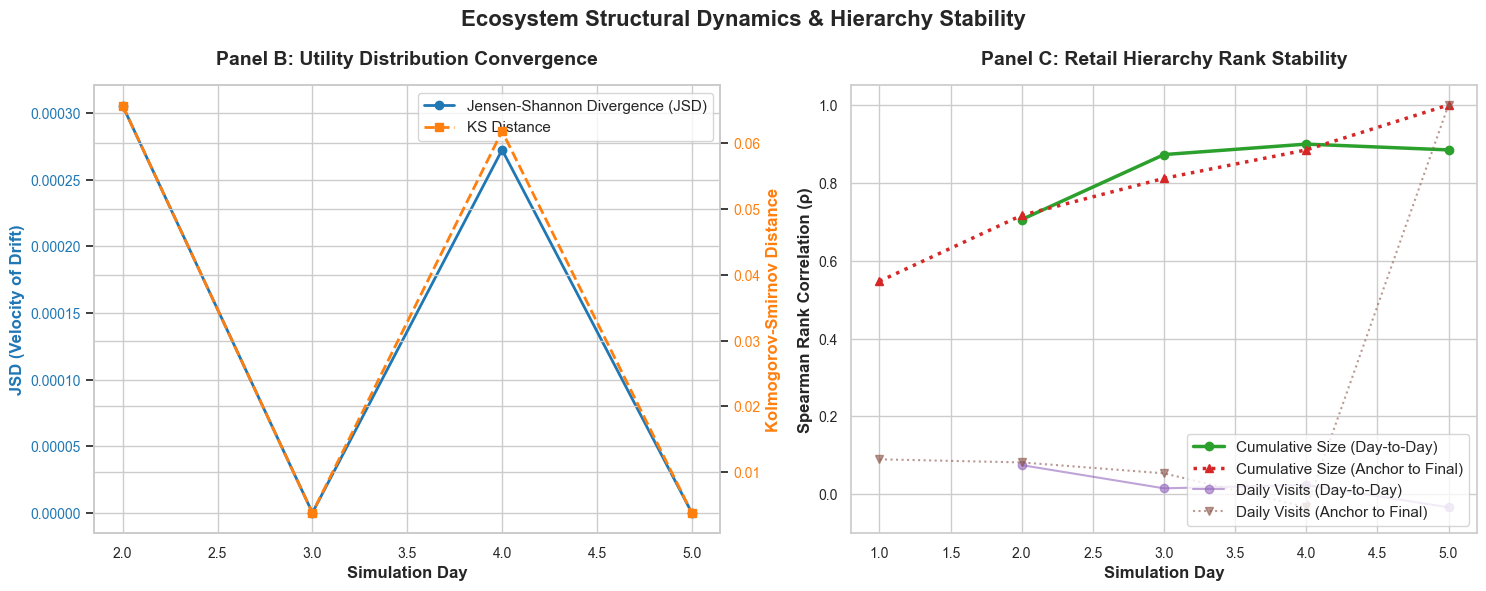

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional publication-quality aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Find the latest convergence CSV file in the outputs directory
outputs_dir = r"C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs"
csv_files = glob.glob(os.path.join(outputs_dir, "utility_convergence_*.csv"))

if not csv_files:
    print("No utility_convergence_*.csv files found in outputs directory.")
    exit(1)

latest_file = max(csv_files, key=os.path.getctime)
print(f"Loading data from: {latest_file}")

df = pd.read_csv(latest_file)

# Create figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =========================================================================
# --- Panel B: Utility Distribution Convergence ---
# =========================================================================
ax1 = axes[0]
color = '#1f77b4'
line1 = ax1.plot(df['Day'], df['JSD'], marker='o', color=color, linewidth=2, label='JSD')
ax1.set_xlabel('Simulation Day', fontweight='bold')
ax1.set_ylabel('JSD (Velocity of Drift)', color=color, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axis sharing the same x-axis for KS distance
ax2 = ax1.twinx()
color = '#ff7f0e'
line2 = ax2.plot(df['Day'], df['KS_Distance'], marker='s', color=color, linewidth=2, linestyle='--', label='KS Distance')
ax2.set_ylabel('Kolmogorov-Smirnov Distance', color=color, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)
ax1.set_title('Panel B: Utility Distribution Convergence', fontweight='bold', pad=15)

# =========================================================================
# --- Panel C: Retail Hierarchy Rank Stability ---
# =========================================================================
ax3 = axes[1]

# Plot Cumulative visit ranks stability
ax3.plot(df['Day'], df['Spearman_Cum_Day_to_Day'], marker='o', color='#2ca02c', linewidth=2.5, label='Cumulative Size (Day-to-Day)')
ax3.plot(df['Day'], df['Spearman_Cum_Final_Anchor'], marker='^', color='#d62728', linewidth=2.5, linestyle=':', label='Cumulative Size (Anchor to Final)')

# Plot Daily visit ranks stability
ax3.plot(df['Day'], df['Spearman_Daily_Day_to_Day'], marker='o', color='#9467bd', linewidth=1.5, alpha=0.6, label='Daily Visits (Day-to-Day)')
ax3.plot(df['Day'], df['Spearman_Daily_Final_Anchor'], marker='v', color='#8c564b', linewidth=1.5, alpha=0.6, linestyle=':', label='Daily Visits (Anchor to Final)')

ax3.set_xlabel('Simulation Day', fontweight='bold')
ax3.set_ylabel('Spearman Rank Correlation (ρ)', fontweight='bold')
ax3.set_ylim(-0.1, 1.05)
ax3.legend(loc='lower right', frameon=True)
ax3.set_title('Panel C: Retail Hierarchy Rank Stability', fontweight='bold', pad=15)

# Adjust layout and save the visualization
plt.suptitle('Ecosystem Structural Dynamics & Hierarchy Stability', fontweight='bold', y=0.98)
plt.tight_layout()

output_img = os.path.join(outputs_dir, "stability_metrics_visualization.png")
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print(f"Visualization saved successfully to: {output_img}")
plt.show()

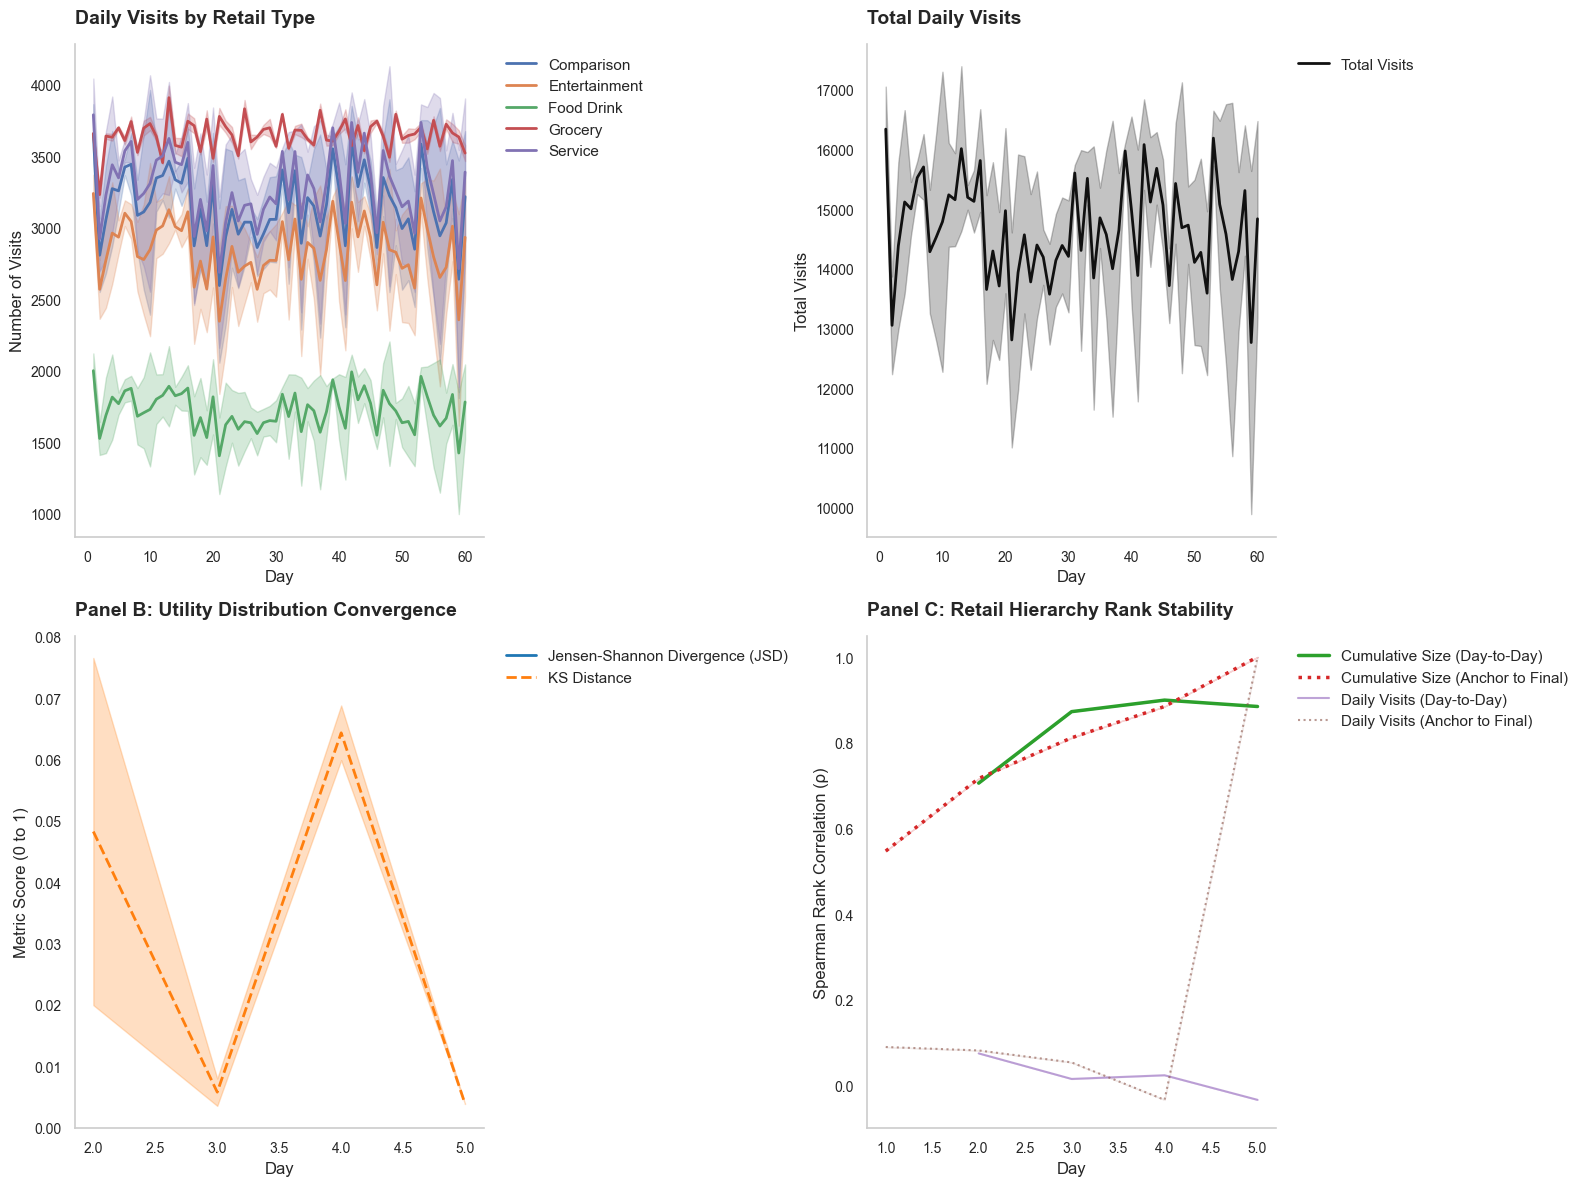

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration & Paths ---
folder = Path(r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\for avg')
conv_folder = Path(r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs')

files = sorted(folder.glob('*.csv'))
conv_files = sorted(conv_folder.glob('utility_convergence_*.csv'))

retail_types = ['comparison', 'entertainment', 'food_drink', 'grocery', 'service']
use_rows = 60

# --- Load and Aggregate Visits Data (Panels 1 & 2) ---
dfs = []
for path in files:
    tmp = pd.read_csv(path)
    if 'Day' not in tmp.columns:
        raise ValueError(f'Missing Day column in {path.name}')
    cols = ['Day'] + [c for c in retail_types + ['Total_Visits'] if c in tmp.columns]
    tmp = tmp.loc[:, cols].head(use_rows).copy()
    dfs.append(tmp)

df_all = pd.concat(dfs, keys=[p.stem for p in files], names=['source']).reset_index(level='source')
agg = df_all.groupby('Day').agg({c: ['mean', 'std'] for c in retail_types + ['Total_Visits']})
agg.columns = [f'{col}_{stat}' for col, stat in agg.columns]
df = agg.reset_index()

for col in retail_types + ['Total_Visits']:
    if f'{col}_std' not in df.columns:
        df[f'{col}_std'] = 0.0
    df[f'{col}_std'] = df[f'{col}_std'].fillna(0.0)

# --- Load and Aggregate Convergence & Rank Stability Data (Panels 3 & 4) ---
conv_dfs = []
for path in conv_files:
    tmp = pd.read_csv(path)
    if 'Day' not in tmp.columns:
        continue
    cols = ['Day', 'JSD', 'KS_Distance', 
            'Spearman_Cum_Day_to_Day', 'Spearman_Cum_Final_Anchor',
            'Spearman_Daily_Day_to_Day', 'Spearman_Daily_Final_Anchor']
    # Select columns that exist in the file
    cols = [c for c in cols if c in tmp.columns]
    tmp = tmp.loc[:, cols].head(use_rows).copy()
    conv_dfs.append(tmp)

if conv_dfs:
    df_conv_all = pd.concat(conv_dfs, keys=[p.stem for p in conv_files], names=['source']).reset_index(level='source')
    metric_cols = [c for c in ['JSD', 'KS_Distance', 
                              'Spearman_Cum_Day_to_Day', 'Spearman_Cum_Final_Anchor',
                              'Spearman_Daily_Day_to_Day', 'Spearman_Daily_Final_Anchor'] 
                   if c in df_conv_all.columns]
    agg_conv = df_conv_all.groupby('Day').agg({c: ['mean', 'std'] for c in metric_cols})
    agg_conv.columns = [f'{col}_{stat}' for col, stat in agg_conv.columns]
    df_conv = agg_conv.reset_index()
    
    for col in metric_cols:
        if f'{col}_std' not in df_conv.columns:
            df_conv[f'{col}_std'] = 0.0
        df_conv[f'{col}_std'] = df_conv[f'{col}_std'].fillna(0.0)
else:
    df_conv = pd.DataFrame()

# --- Plotting: 2x2 Grid (4 Panels) ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Daily Visits by Retail Type
for col in retail_types:
    legend_name = col.replace('_', ' ').title()
    line, = ax1.plot(df['Day'], df[f'{col}_mean'], linewidth=2, label=legend_name)
    color = line.get_color()
    lower = df[f'{col}_mean'] - df[f'{col}_std']
    upper = df[f'{col}_mean'] + df[f'{col}_std']
    ax1.fill_between(df['Day'], lower, upper, color=color, alpha=0.25)

ax1.set_title('Daily Visits by Retail Type', fontweight='bold', loc='left', pad=15)
ax1.set_xlabel('Day')
ax1.set_ylabel('Number of Visits')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)
ax1.tick_params(width=1.2)
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax1.grid(False)

# Panel 2: Total Daily Visits
line, = ax2.plot(df['Day'], df['Total_Visits_mean'], linewidth=2, color='#111111', label='Total Visits')
color = line.get_color()
lower_total = df['Total_Visits_mean'] - df['Total_Visits_std']
upper_total = df['Total_Visits_mean'] + df['Total_Visits_std']
ax2.fill_between(df['Day'], lower_total, upper_total, color=color, alpha=0.25)

ax2.set_title('Total Daily Visits', fontweight='bold', loc='left', pad=15)
ax2.set_xlabel('Day')
ax2.set_ylabel('Total Visits')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)
ax2.tick_params(width=1.2)
ax2.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax2.grid(False)

# Panel 3: Utility Distribution Convergence
if not df_conv.empty and 'JSD_mean' in df_conv.columns:
    # JSD
    line1, = ax3.plot(df_conv['Day'], df_conv['JSD_mean'], linewidth=2, color='#1f77b4', label='JSD')
    color1 = line1.get_color()
    lower_jsd = df_conv['JSD_mean'] - df_conv['JSD_std']
    upper_jsd = df_conv['JSD_mean'] + df_conv['JSD_std']
    ax3.fill_between(df_conv['Day'], lower_jsd, upper_jsd, color=color1, alpha=0.25)
    
    # KS Distance
    line2, = ax3.plot(df_conv['Day'], df_conv['KS_Distance_mean'], linewidth=2, color='#ff7f0e', linestyle='--', label='KS Distance')
    color2 = line2.get_color()
    lower_ks = df_conv['KS_Distance_mean'] - df_conv['KS_Distance_std']
    upper_ks = df_conv['KS_Distance_mean'] + df_conv['KS_Distance_std']
    ax3.fill_between(df_conv['Day'], lower_ks, upper_ks, color=color2, alpha=0.25)

ax3.set_title('Panel B: Utility Distribution Convergence', fontweight='bold', loc='left', pad=15)
ax3.set_xlabel('Day')
ax3.set_ylabel('Metric Score (0 to 1)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_linewidth(1.2)
ax3.spines['bottom'].set_linewidth(1.2)
ax3.tick_params(width=1.2)
ax3.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax3.grid(False)

# Panel 4: Retail Hierarchy Rank Stability
if not df_conv.empty and 'Spearman_Cum_Day_to_Day_mean' in df_conv.columns:
    # Cumulative Day-to-Day
    line_c1, = ax4.plot(df_conv['Day'], df_conv['Spearman_Cum_Day_to_Day_mean'], linewidth=2.5, color='#2ca02c', label='Cumulative Size (Day-to-Day)')
    color_c1 = line_c1.get_color()
    l_c1 = df_conv['Spearman_Cum_Day_to_Day_mean'] - df_conv['Spearman_Cum_Day_to_Day_std']
    u_c1 = df_conv['Spearman_Cum_Day_to_Day_mean'] + df_conv['Spearman_Cum_Day_to_Day_std']
    ax4.fill_between(df_conv['Day'], l_c1, u_c1, color=color_c1, alpha=0.2)
    
    # Cumulative Anchor to Final
    line_c2, = ax4.plot(df_conv['Day'], df_conv['Spearman_Cum_Final_Anchor_mean'], linewidth=2.5, color='#d62728', linestyle=':', label='Cumulative Size (Anchor to Final)')
    color_c2 = line_c2.get_color()
    l_c2 = df_conv['Spearman_Cum_Final_Anchor_mean'] - df_conv['Spearman_Cum_Final_Anchor_std']
    u_c2 = df_conv['Spearman_Cum_Final_Anchor_mean'] + df_conv['Spearman_Cum_Final_Anchor_std']
    ax4.fill_between(df_conv['Day'], l_c2, u_c2, color=color_c2, alpha=0.2)

    # Daily Day-to-Day
    line_d1, = ax4.plot(df_conv['Day'], df_conv['Spearman_Daily_Day_to_Day_mean'], linewidth=1.5, color='#9467bd', alpha=0.6, label='Daily Visits (Day-to-Day)')
    color_d1 = line_d1.get_color()
    l_d1 = df_conv['Spearman_Daily_Day_to_Day_mean'] - df_conv['Spearman_Daily_Day_to_Day_std']
    u_d1 = df_conv['Spearman_Daily_Day_to_Day_mean'] + df_conv['Spearman_Daily_Day_to_Day_std']
    ax4.fill_between(df_conv['Day'], l_d1, u_d1, color=color_d1, alpha=0.1)

    # Daily Anchor to Final
    line_d2, = ax4.plot(df_conv['Day'], df_conv['Spearman_Daily_Final_Anchor_mean'], linewidth=1.5, color='#8c564b', alpha=0.6, linestyle=':', label='Daily Visits (Anchor to Final)')
    color_d2 = line_d2.get_color()
    l_d2 = df_conv['Spearman_Daily_Final_Anchor_mean'] - df_conv['Spearman_Daily_Final_Anchor_std']
    u_d2 = df_conv['Spearman_Daily_Final_Anchor_mean'] + df_conv['Spearman_Daily_Final_Anchor_std']
    ax4.fill_between(df_conv['Day'], l_d2, u_d2, color=color_d2, alpha=0.1)

ax4.set_title('Panel C: Retail Hierarchy Rank Stability', fontweight='bold', loc='left', pad=15)
ax4.set_xlabel('Day')
ax4.set_ylabel('Spearman Rank Correlation (ρ)')
ax4.set_ylim(-0.1, 1.05)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_linewidth(1.2)
ax4.spines['bottom'].set_linewidth(1.2)
ax4.tick_params(width=1.2)
ax4.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax4.grid(False)

plt.tight_layout()
plt.show()

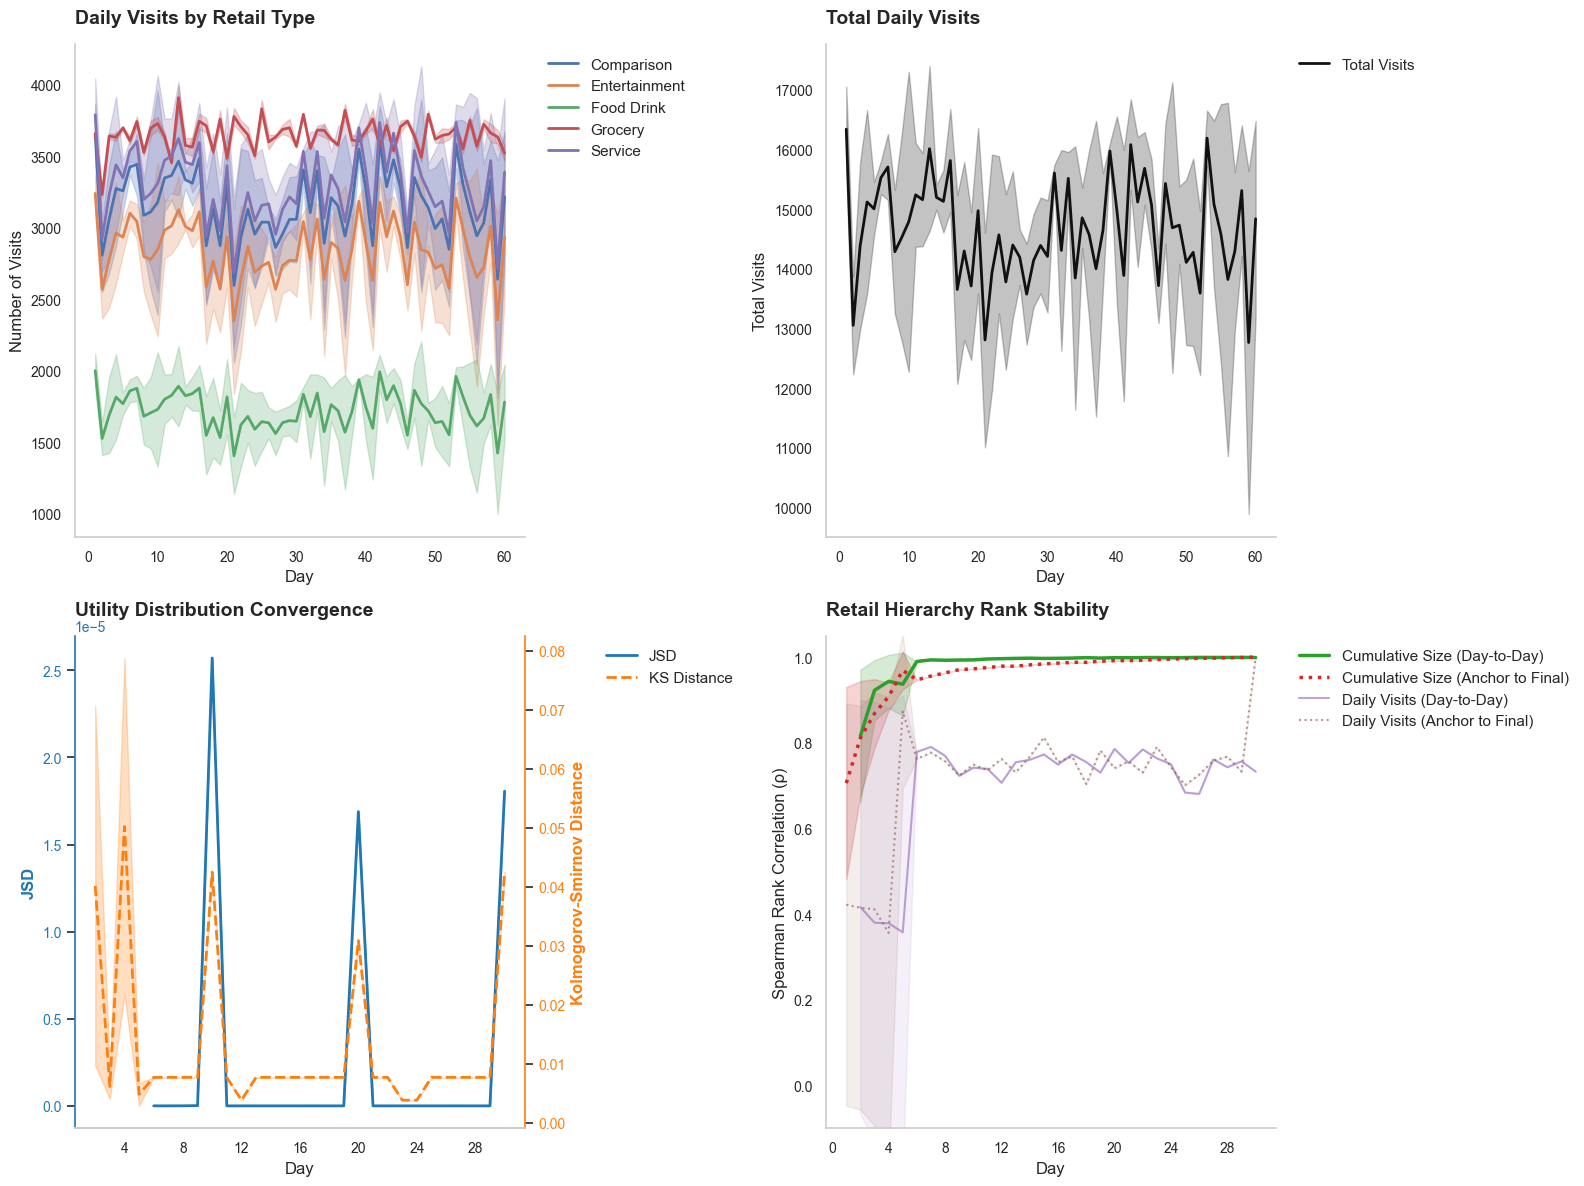

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration & Paths ---
folder = Path(r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\for avg')
conv_folder = Path(r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs')

files = sorted(folder.glob('*.csv'))
conv_files = sorted(conv_folder.glob('utility_convergence_*.csv'))

retail_types = ['comparison', 'entertainment', 'food_drink', 'grocery', 'service']
use_rows = 60

# --- Load and Aggregate Visits Data (Panels 1 & 2) ---
dfs = []
for path in files:
    tmp = pd.read_csv(path)
    if 'Day' not in tmp.columns:
        raise ValueError(f'Missing Day column in {path.name}')
    cols = ['Day'] + [c for c in retail_types + ['Total_Visits'] if c in tmp.columns]
    tmp = tmp.loc[:, cols].head(use_rows).copy()
    dfs.append(tmp)

df_all = pd.concat(dfs, keys=[p.stem for p in files], names=['source']).reset_index(level='source')
agg = df_all.groupby('Day').agg({c: ['mean', 'std'] for c in retail_types + ['Total_Visits']})
agg.columns = [f'{col}_{stat}' for col, stat in agg.columns]
df = agg.reset_index()

for col in retail_types + ['Total_Visits']:
    if f'{col}_std' not in df.columns:
        df[f'{col}_std'] = 0.0
    df[f'{col}_std'] = df[f'{col}_std'].fillna(0.0)

# --- Load and Aggregate Convergence & Rank Stability Data (Panels 3 & 4) ---
conv_dfs = []
for path in conv_files:
    tmp = pd.read_csv(path)
    if 'Day' not in tmp.columns:
        continue
    cols = ['Day', 'JSD', 'KS_Distance', 
            'Spearman_Cum_Day_to_Day', 'Spearman_Cum_Final_Anchor',
            'Spearman_Daily_Day_to_Day', 'Spearman_Daily_Final_Anchor']
    # Select columns that exist in the file
    cols = [c for c in cols if c in tmp.columns]
    tmp = tmp.loc[:, cols].head(use_rows).copy()
    conv_dfs.append(tmp)

if conv_dfs:
    df_conv_all = pd.concat(conv_dfs, keys=[p.stem for p in conv_files], names=['source']).reset_index(level='source')
    metric_cols = [c for c in ['JSD', 'KS_Distance', 
                              'Spearman_Cum_Day_to_Day', 'Spearman_Cum_Final_Anchor',
                              'Spearman_Daily_Day_to_Day', 'Spearman_Daily_Final_Anchor'] 
                   if c in df_conv_all.columns]
    agg_conv = df_conv_all.groupby('Day').agg({c: ['mean', 'std'] for c in metric_cols})
    agg_conv.columns = [f'{col}_{stat}' for col, stat in agg_conv.columns]
    df_conv = agg_conv.reset_index()
    
    for col in metric_cols:
        if f'{col}_std' not in df_conv.columns:
            df_conv[f'{col}_std'] = 0.0
        df_conv[f'{col}_std'] = df_conv[f'{col}_std'].fillna(0.0)
else:
    df_conv = pd.DataFrame()

# --- Plotting: 2x2 Grid (4 Panels) ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Daily Visits by Retail Type
for col in retail_types:
    legend_name = col.replace('_', ' ').title()
    line, = ax1.plot(df['Day'], df[f'{col}_mean'], linewidth=2, label=legend_name)
    color = line.get_color()
    lower = df[f'{col}_mean'] - df[f'{col}_std']
    upper = df[f'{col}_mean'] + df[f'{col}_std']
    ax1.fill_between(df['Day'], lower, upper, color=color, alpha=0.25)

ax1.set_title('Daily Visits by Retail Type', fontweight='bold', loc='left', pad=15)
ax1.set_xlabel('Day')
ax1.set_ylabel('Number of Visits')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)
ax1.tick_params(width=1.2)
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax1.grid(False)

# Panel 2: Total Daily Visits
line, = ax2.plot(df['Day'], df['Total_Visits_mean'], linewidth=2, color='#111111', label='Total Visits')
color = line.get_color()
lower_total = df['Total_Visits_mean'] - df['Total_Visits_std']
upper_total = df['Total_Visits_mean'] + df['Total_Visits_std']
ax2.fill_between(df['Day'], lower_total, upper_total, color=color, alpha=0.25)

ax2.set_title('Total Daily Visits', fontweight='bold', loc='left', pad=15)
ax2.set_xlabel('Day')
ax2.set_ylabel('Total Visits')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)
ax2.tick_params(width=1.2)
ax2.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax2.grid(False)

# Panel 3: Utility Distribution Convergence (with twin y-axis)
if not df_conv.empty and 'JSD_mean' in df_conv.columns:
    # JSD (Left y-axis)
    color_jsd = '#1f77b4'
    line1, = ax3.plot(df_conv['Day'], df_conv['JSD_mean'], linewidth=2, color=color_jsd, label='JSD')
    lower_jsd = df_conv['JSD_mean'] - df_conv['JSD_std']
    upper_jsd = df_conv['JSD_mean'] + df_conv['JSD_std']
    ax3.fill_between(df_conv['Day'], lower_jsd, upper_jsd, color=color_jsd, alpha=0.25)
    
    ax3.set_ylabel('JSD', color=color_jsd, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor=color_jsd, width=1.2)
    ax3.spines['left'].set_color(color_jsd)
    ax3.spines['left'].set_linewidth(1.2)

    # KS Distance (Right y-axis sharing same x-axis)
    ax3_twin = ax3.twinx()
    color_ks = '#ff7f0e'
    line2, = ax3_twin.plot(df_conv['Day'], df_conv['KS_Distance_mean'], linewidth=2, color=color_ks, linestyle='--', label='KS Distance')
    lower_ks = df_conv['KS_Distance_mean'] - df_conv['KS_Distance_std']
    upper_ks = df_conv['KS_Distance_mean'] + df_conv['KS_Distance_std']
    ax3_twin.fill_between(df_conv['Day'], lower_ks, upper_ks, color=color_ks, alpha=0.25)
    
    ax3_twin.set_ylabel('Kolmogorov-Smirnov Distance', color=color_ks, fontweight='bold')
    ax3_twin.tick_params(axis='y', labelcolor=color_ks, width=1.2)
    ax3_twin.spines['right'].set_color(color_ks)
    ax3_twin.spines['right'].set_linewidth(1.2)
    ax3_twin.spines['right'].set_visible(True)
    ax3_twin.spines['top'].set_visible(False)
    ax3_twin.spines['left'].set_visible(False)
    ax3_twin.grid(False)

    # Clean up primary axes spines
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['bottom'].set_linewidth(1.2)
    ax3.tick_params(axis='x', width=1.2)
    ax3.grid(False)
    
    # Combined legend positioned to clear the twin labels
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, frameon=False, loc='upper left', bbox_to_anchor=(1.15, 1))
    
    # Force integer labels on X-axis (days)
    ax3.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax3.set_title('Utility Distribution Convergence', fontweight='bold', loc='left', pad=15)
ax3.set_xlabel('Day')

# Panel 4: Retail Hierarchy Rank Stability
if not df_conv.empty and 'Spearman_Cum_Day_to_Day_mean' in df_conv.columns:
    # Cumulative Day-to-Day
    line_c1, = ax4.plot(df_conv['Day'], df_conv['Spearman_Cum_Day_to_Day_mean'], linewidth=2.5, color='#2ca02c', label='Cumulative Size (Day-to-Day)')
    color_c1 = line_c1.get_color()
    l_c1 = df_conv['Spearman_Cum_Day_to_Day_mean'] - df_conv['Spearman_Cum_Day_to_Day_std']
    u_c1 = df_conv['Spearman_Cum_Day_to_Day_mean'] + df_conv['Spearman_Cum_Day_to_Day_std']
    ax4.fill_between(df_conv['Day'], l_c1, u_c1, color=color_c1, alpha=0.2)
    
    # Cumulative Anchor to Final
    line_c2, = ax4.plot(df_conv['Day'], df_conv['Spearman_Cum_Final_Anchor_mean'], linewidth=2.5, color='#d62728', linestyle=':', label='Cumulative Size (Anchor to Final)')
    color_c2 = line_c2.get_color()
    l_c2 = df_conv['Spearman_Cum_Final_Anchor_mean'] - df_conv['Spearman_Cum_Final_Anchor_std']
    u_c2 = df_conv['Spearman_Cum_Final_Anchor_mean'] + df_conv['Spearman_Cum_Final_Anchor_std']
    ax4.fill_between(df_conv['Day'], l_c2, u_c2, color=color_c2, alpha=0.2)

    # Daily Day-to-Day
    line_d1, = ax4.plot(df_conv['Day'], df_conv['Spearman_Daily_Day_to_Day_mean'], linewidth=1.5, color='#9467bd', alpha=0.6, label='Daily Visits (Day-to-Day)')
    color_d1 = line_d1.get_color()
    l_d1 = df_conv['Spearman_Daily_Day_to_Day_mean'] - df_conv['Spearman_Daily_Day_to_Day_std']
    u_d1 = df_conv['Spearman_Daily_Day_to_Day_mean'] + df_conv['Spearman_Daily_Day_to_Day_std']
    ax4.fill_between(df_conv['Day'], l_d1, u_d1, color=color_d1, alpha=0.1)

    # Daily Anchor to Final
    line_d2, = ax4.plot(df_conv['Day'], df_conv['Spearman_Daily_Final_Anchor_mean'], linewidth=1.5, color='#8c564b', alpha=0.6, linestyle=':', label='Daily Visits (Anchor to Final)')
    color_d2 = line_d2.get_color()
    l_d2 = df_conv['Spearman_Daily_Final_Anchor_mean'] - df_conv['Spearman_Daily_Final_Anchor_std']
    u_d2 = df_conv['Spearman_Daily_Final_Anchor_mean'] + df_conv['Spearman_Daily_Final_Anchor_std']
    ax4.fill_between(df_conv['Day'], l_d2, u_d2, color=color_d2, alpha=0.1)

    # Force integer labels on X-axis (days)
    ax4.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax4.set_title('Retail Hierarchy Rank Stability', fontweight='bold', loc='left', pad=15)
ax4.set_xlabel('Day')
ax4.set_ylabel('Spearman Rank Correlation (ρ)')
ax4.set_ylim(-0.1, 1.05)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_linewidth(1.2)
ax4.spines['bottom'].set_linewidth(1.2)
ax4.tick_params(width=1.2)
ax4.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax4.grid(False)

plt.tight_layout()
plt.show()